In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [3]:
# 1. Load dataset
df = pd.read_csv('train.csv', parse_dates=['datetime'])

In [4]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


# 2. Exploratory Data Analytics---EDA 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [6]:
#Summary Statistics
df.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


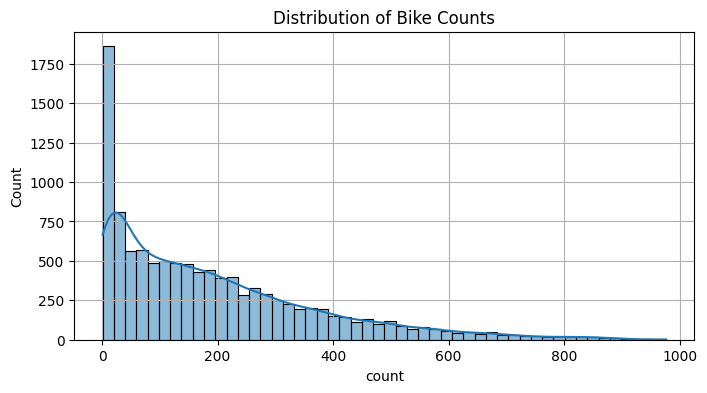

In [15]:
# Bike distribution of rental count (right skewed)
plt.figure(figsize=(8, 4))
sns.histplot(df['count'], bins=50, kde=True)
plt.title('Distribution of Bike Counts')
plt.grid(True)
plt.show()

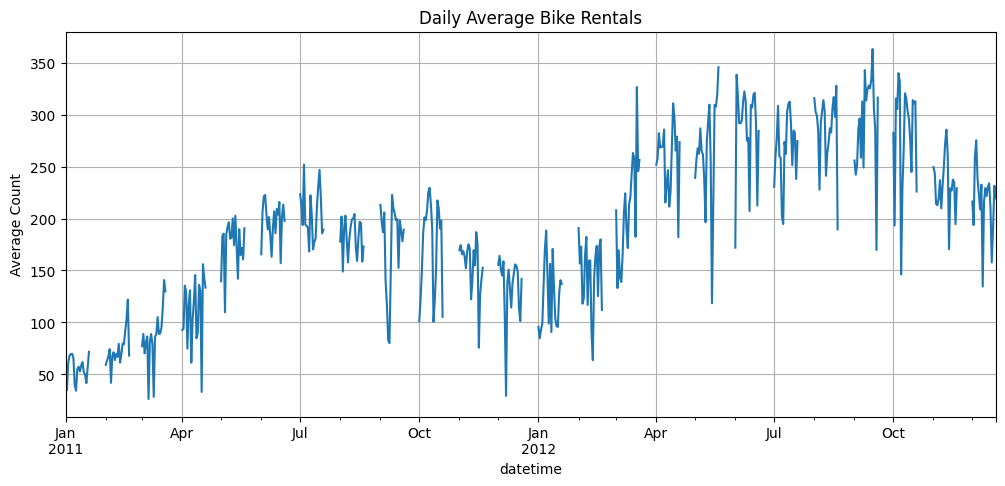

In [16]:
# the mean number of rentals per day
plt.figure(figsize=(12, 5))
df.set_index('datetime')['count'].resample('D').mean().plot()
plt.title('Daily Average Bike Rentals')
plt.ylabel('Average Count')
plt.grid(True)
plt.show()

# 3. Feature engineering

In [17]:
# Feature construction
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

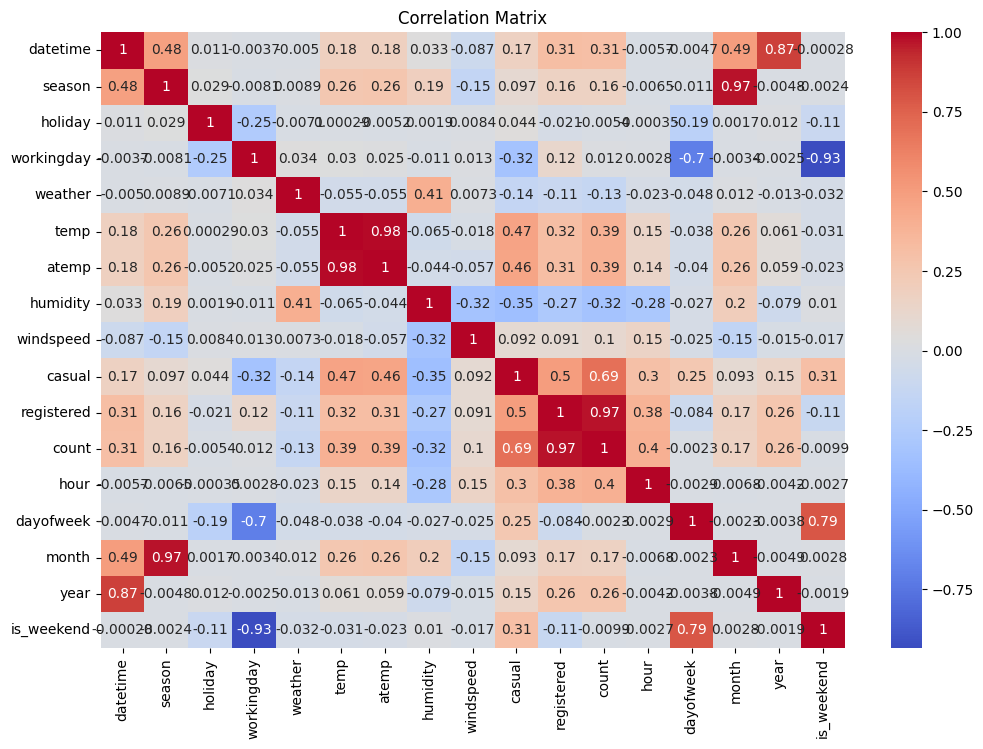

In [18]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

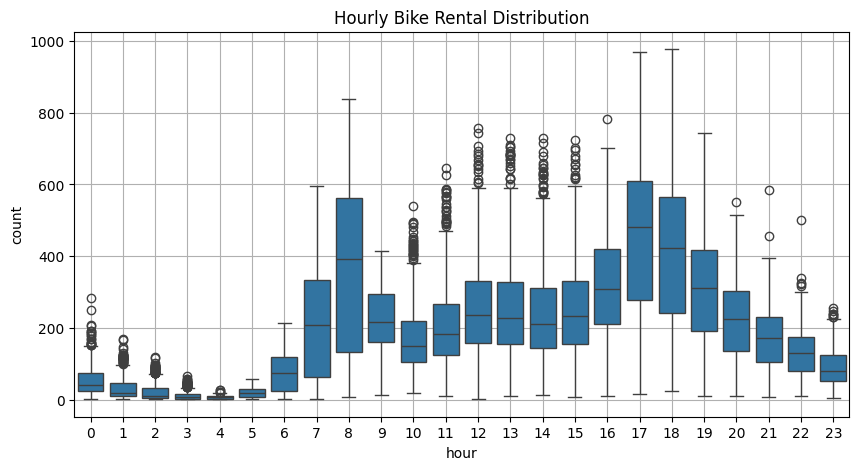

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='hour', y='count', data=df)
plt.title('Hourly Bike Rental Distribution')
plt.grid(True)
plt.show()

In [20]:
# Remove outliers
df = df[df['count'] <= df['count'].quantile(0.99)]

In [21]:
# 5. Features & target
features = ['season', 'holiday', 'workingday', 'weather',
            'temp', 'humidity', 'windspeed',
            'hour', 'dayofweek', 'month', 'year', 'is_weekend']
X = df[features]
y = df['count']

#  Data Preprocessing

In [22]:
categorical = ['season', 'holiday', 'workingday', 'weather', 'hour', 'dayofweek', 'month', 'year', 'is_weekend']
numeric = ['temp', 'humidity', 'windspeed']
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', 'passthrough', numeric)
])

In [23]:
# 7. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# 8. Model 1: Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=2, random_state=42))
])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [25]:
# 9. Model 2: Linear Regression
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [26]:
# Cross-validation comparison
rf_cv_score = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
lr_cv_score = cross_val_score(lr_model, X, y, cv=5, scoring='r2')

In [27]:
# 11. Evaluation Metrics
print("\n Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R^2:", r2_score(y_test, rf_pred))
print("Cross-Validated R^2:", np.mean(rf_cv_score))


 Random Forest Results
MAE: 35.39841791946975
RMSE: 53.841492790555954
R^2: 0.8982029118956056
Cross-Validated R^2: 0.6377592229170143


In [28]:
print("\n Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R^2:", r2_score(y_test, lr_pred))
print("Cross-Validated R^2:", np.mean(lr_cv_score))


 Linear Regression Results
MAE: 71.33355510374462
RMSE: 95.85417674721218
R^2: 0.6773562524702339
Cross-Validated R^2: 0.5296765690194591


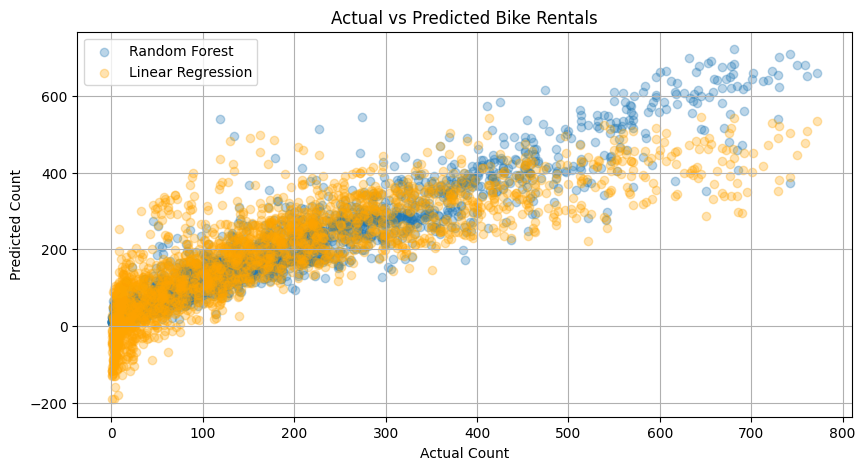

In [29]:
# 12. Visualization
plt.figure(figsize=(10, 5))
plt.scatter(y_test, rf_pred, alpha=0.3, label='Random Forest')
plt.scatter(y_test, lr_pred, alpha=0.3, label='Linear Regression', color='orange')
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.legend()
plt.title('Actual vs Predicted Bike Rentals')
plt.grid(True)
plt.show()

In [30]:
#  Confusion Matrix (handle NaNs)
bins = [0, 20, 50, 100, 200, 500, 1000, np.inf]
y_test_binned = pd.cut(y_test, bins=bins, labels=False)
rf_pred_binned = pd.cut(rf_pred, bins=bins, labels=False)
lr_pred_binned = pd.cut(lr_pred, bins=bins, labels=False)

# Fill any NaNs with -1 for safe comparison (to avoid dropping any data point)
valid_mask = (~pd.isna(y_test_binned)) & (~pd.isna(rf_pred_binned)) & (~pd.isna(lr_pred_binned))

cm_rf = confusion_matrix(y_test_binned[valid_mask], rf_pred_binned[valid_mask])
cm_lr = confusion_matrix(y_test_binned[valid_mask], lr_pred_binned[valid_mask])

In [31]:
from sklearn.metrics import classification_report
print("\n Confusion Matrix: Random Forest")
print(cm_rf)
print("\n Classification Report: Random Forest")
print(classification_report(y_test_binned[valid_mask], rf_pred_binned[valid_mask]))


 Confusion Matrix: Random Forest
[[118  58  18   3   0   0]
 [  7  89  59  15   1   0]
 [  2  18 136 101   8   0]
 [  0   1  30 364  97   1]
 [  0   0   1  86 578  12]
 [  0   0   0   0  38 101]]

 Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.93      0.60      0.73       197
           1       0.54      0.52      0.53       171
           2       0.56      0.51      0.53       265
           3       0.64      0.74      0.69       493
           4       0.80      0.85      0.83       677
           5       0.89      0.73      0.80       139

    accuracy                           0.71      1942
   macro avg       0.72      0.66      0.68      1942
weighted avg       0.72      0.71      0.71      1942



In [32]:
print("\n Confusion Matrix: Linear Regression")
print(cm_lr)
print("\n Classification Report: Linear Regression")
print(classification_report(y_test_binned[valid_mask], lr_pred_binned[valid_mask]))


 Confusion Matrix: Linear Regression
[[ 49  39  70  38   1   0]
 [ 22  39  52  50   8   0]
 [  8  26  71 120  40   0]
 [  1   5  39 223 225   0]
 [  0   0   0  72 603   2]
 [  0   0   0   0 124  15]]

 Classification Report: Linear Regression
              precision    recall  f1-score   support

           0       0.61      0.25      0.35       197
           1       0.36      0.23      0.28       171
           2       0.31      0.27      0.29       265
           3       0.44      0.45      0.45       493
           4       0.60      0.89      0.72       677
           5       0.88      0.11      0.19       139

    accuracy                           0.51      1942
   macro avg       0.53      0.37      0.38      1942
weighted avg       0.52      0.51      0.48      1942



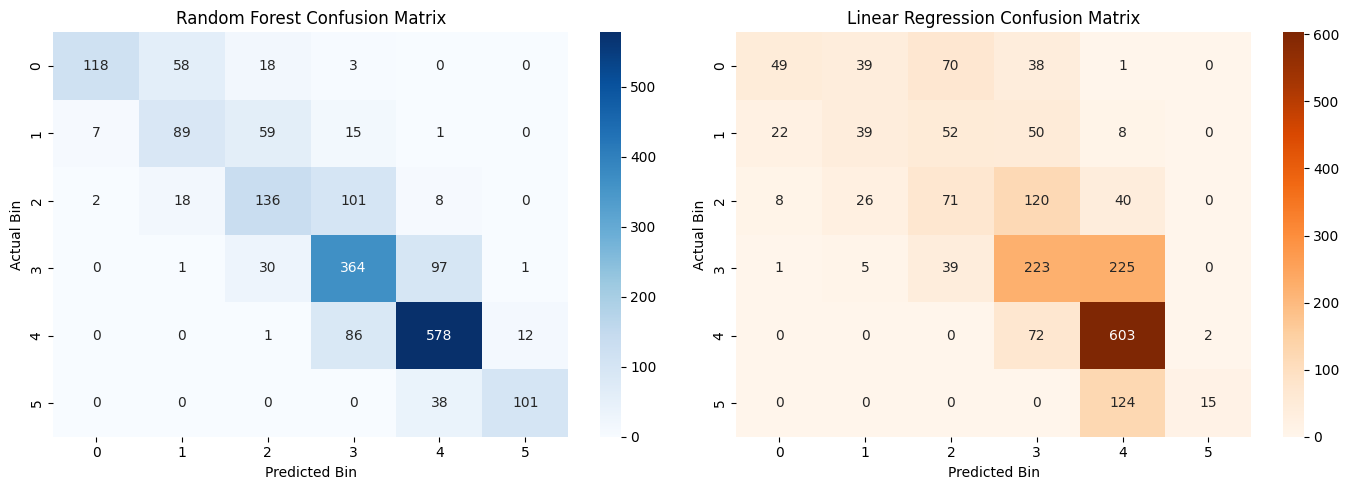

In [33]:
# Plot Confusion Matrix
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Bin')
plt.ylabel('Actual Bin')

plt.subplot(1, 2, 2)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges')
plt.title('Linear Regression Confusion Matrix')
plt.xlabel('Predicted Bin')
plt.ylabel('Actual Bin')

plt.tight_layout()
plt.show()

In [34]:
# 14. Feature Importance from Random Forest
importances = rf_model.named_steps['regressor'].feature_importances_
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("\n Top 10 Feature Importances (Random Forest)")
print(feat_importances.head(10))


 Top 10 Feature Importances (Random Forest)
num__temp            0.162197
num__humidity        0.141772
cat__hour_8          0.073267
cat__hour_17         0.062339
cat__hour_18         0.059197
cat__year_2011       0.038184
cat__hour_19         0.035229
cat__year_2012       0.034814
cat__workingday_1    0.033634
cat__workingday_0    0.031110
dtype: float64


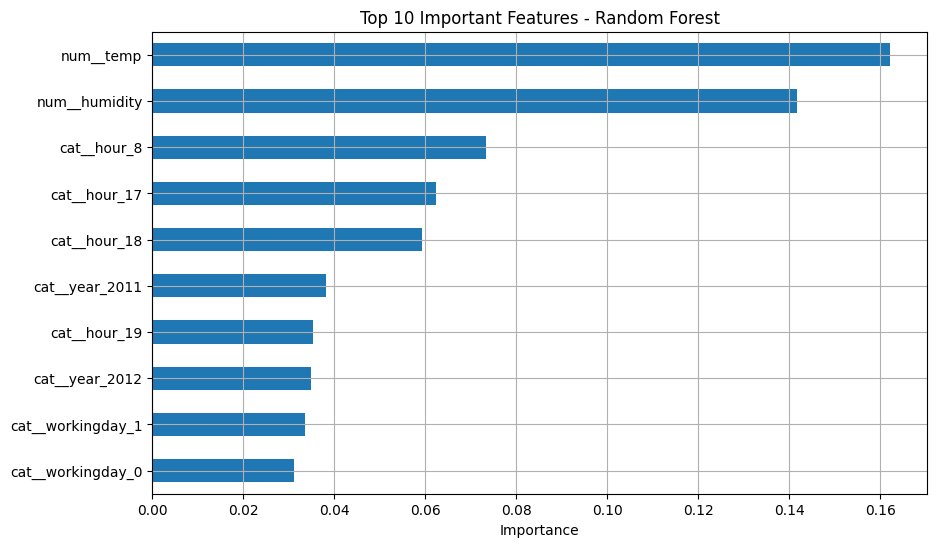

In [35]:
# Plot feature importance
plt.figure(figsize=(10, 6))
feat_importances.head(10).plot(kind='barh')
plt.title('Top 10 Important Features - Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()